In [1]:
import xarray as xr
import datetime as dt
import pandas as pd
from tqdm import tqdm
from glob import glob
from braceexpand import braceexpand
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle
from scipy.stats import linregress
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import open_files, calculate_ranking

In [2]:
def braced_glob(path):
    l = []
    for x in braceexpand(path):
        l.extend(glob(x))          
    return l

In [3]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    Possible and slightly more precise with geopy or pyproj through xr.apply_ufunc but longer
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [22]:
quantile = 0.999

df, _ = open_files('ERA5')

In [23]:
(
    sorted_EETC_cum_rank,
    sorted_EETC_cum_avg_rank,
    sorted_EETC_cum_SSI_rank,
    sorted_EETC_cum_avg_SSI_rank,
    _,
    _,
    _,
    _,
    EETC_dict,
    _
) = calculate_ranking(sim='ERA5', quantile=quantile, ref=False, method='product')

In [24]:
# for storm in EETC_dict:
#     if EETC_dict[storm]['cum_precip'].sel(quantile=quantile).values or EETC_dict[storm]['cum_avg_precip'].sel(quantile=quantile).values or EETC_dict[storm]['cum_wind'].sel(quantile=quantile).values or EETC_dict[storm]['cum_avg_wind'].sel(quantile=quantile).values or EETC_dict[storm]['SSI'].sel(quantile=quantile).values != 0:
#         storm_group = df.groupby('storm').get_group(storm)
#         min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
#         EETC_dict[storm]['min_pressure_date'] = min_pressure_row['date']

## Préparation au tracé des cartes

In [25]:
positions = [
    [0.05, 0.45, 0.29, 0.50],  # Rangée du haut, Colonne 1
    [0.35, 0.45, 0.29, 0.50],  # Rangée du haut, Colonne 2
    [0.65, 0.45, 0.29, 0.50],  # Rangée du haut, Colonne 3
    [0.05, 0.11, 0.29, 0.50],  # Rangée du bas,  Colonne 1
    [0.35, 0.11, 0.29, 0.50],  # Rangée du bas,  Colonne 2
    [0.65, 0.11, 0.29, 0.50],  # Rangée du bas,  Colonne 3
]

percentile_precip = xr.open_dataset(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR_Percentile/pr_era5_percentile.nc')
percentile_wind = xr.open_dataset(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/WIND_Percentile/surf_wind_era5_percentile.nc')

west_longitude = -80
east_longitude = -66
north_latitude = 55
south_latitude = 44

Mask_NNA = xr.DataArray(
np.zeros((len(percentile_precip['latitude']), len(percentile_precip['longitude']))),
coords={'latitude': percentile_precip['latitude'], 'longitude': percentile_precip['longitude']},
dims=['latitude', 'longitude']
)

Mask_NNA.loc[
    dict(longitude=slice(west_longitude, east_longitude), 
         latitude=slice(north_latitude, south_latitude))
] = 1

## Tracé des cartes

In [ ]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 13))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, ax in tqdm(enumerate(axes)):    
    
    max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_rank[i])
    
    min_pressure_row = max_EETC.loc[max_EETC['pressure'].idxmin()]
    EETC_dict[sorted_EETC_cum_rank[i]]['min_pressure_date'] = min_pressure_row['date']
    
    month_years = max_EETC['date'].dt.to_period('M').unique()
    filenames = []
    for period in month_years:
        year = period.year
        month = period.month
        filenames.extend(braced_glob(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR/{year}/{month:02d}/era5_tp_ll_*_1h.nc4'))
    ds = xr.open_mfdataset(filenames)
    ds = ds.rename({'tp': 'pr'})
    ds = ds.assign_coords({'longitude':(((ds['longitude'] + 180) % 360) - 180)})
    ds = ds.sortby(ds['longitude'])
    ds = ds.sel(longitude=slice(-171, -23), latitude=slice(76, 12))
    ds['pr'] = ds.pr * 1000.
    mask_diff_precip = ds - percentile_precip
    mask_diff_precip = mask_diff_precip.where(mask_diff_precip >= 0, np.nan)
    
    iEETC_list_precip = []
    for itrack, row in max_EETC.iterrows():        
        ilon, ilat, itime = row['lon'], row['lat'], row['date']

        mask_itime_precip = mask_diff_precip.sel(time=itime).where(mask_diff_precip.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).pr
        
        iEETC_list_precip.append(mask_itime_precip.chunk({'longitude': -1, 'latitude': -1, 'quantile': -1}))

    iEETC_precip = xr.concat(iEETC_list_precip, dim='time') 
    iEETC_precip_exc = iEETC_precip.sum(dim=['time']) 

    ax.set_extent([-120, -50, 70, 25], crs=ccrs.PlateCarree())

    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

    # mtl_lon, mtl_lat = -73.561668, 45.508888
    # ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

    vmin = 0
    vmax = 24
    cmap = plt.get_cmap('jet')

    ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=3, c='white', alpha=0.7, marker='o', markersize=3)

    iEETC_precip_exc = iEETC_precip_exc.where(iEETC_precip_exc > 0, np.nan)

    # sc = ax.contourf(iEETC_precip_exc['longitude'], iEETC_precip_exc['latitude'],
    #                  iEETC_precip_exc.sel(quantile=quantile), levels=np.linspace(vmin, vmax, int((vmax-vmin)/2)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
    sc = ax.pcolormesh(iEETC_precip_exc['longitude'], iEETC_precip_exc['latitude'],
                 iEETC_precip_exc.sel(quantile=quantile), vmin=vmin, vmax=vmax, cmap=cmap, transform=ccrs.PlateCarree())

    ax.contour(
        Mask_NNA['longitude'],
        Mask_NNA['latitude'],
        Mask_NNA,
        levels=[0.99],
        linewidths=3,
        colors='black',
        alpha=0.75,
        transform=ccrs.PlateCarree(),
    )
    
    ax.text(
        0.01, 0.985,
        r"$EE_{PR,cum}^{ERA5}|_{QC} = $"f"{np.round(EETC_dict[sorted_EETC_cum_rank[i]]['cum_precip'].sel(quantile=quantile).values.item(), 2)} mm",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='k', alpha=0.7)
    )
    
    ax.text(
        0.875, 0.05,
        f"{EETC_dict[sorted_EETC_cum_rank[i]]['min_pressure_date'].month}-{EETC_dict[sorted_EETC_cum_rank[i]]['min_pressure_date'].year}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='k', alpha=0.7)
    )
        
        
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
# cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 4))
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, extend='max', aspect=40)
# cbar.set_label('Precipitation exceedance (mm)', fontsize=15)
cbar.set_label(r'$EE_{PR,cum}^{ERA5}(x)$ [mm]', fontsize=18)
cbar.ax.tick_params(labelsize=16)

# fig.suptitle(
#     'Precipitation exceedance (99th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
#     'based on the product of $ETC_{PR, cum}$ . $ETC_{WS, cum}$', 
#     fontsize=22, y=0.93
# )

6it [04:56, 49.41s/it]


## A partir de là, qq modif à faire

6it [06:21, 63.56s/it]


Text(0.5, 0.93, 'Surface wind exceedance (99.9th percentile) of the 6 most severe ETC of 1979-2023 in Québec\nbased on the cumulative ranking of $ETC_{PR, cum}$ . $ETC_{WS, cum}$')

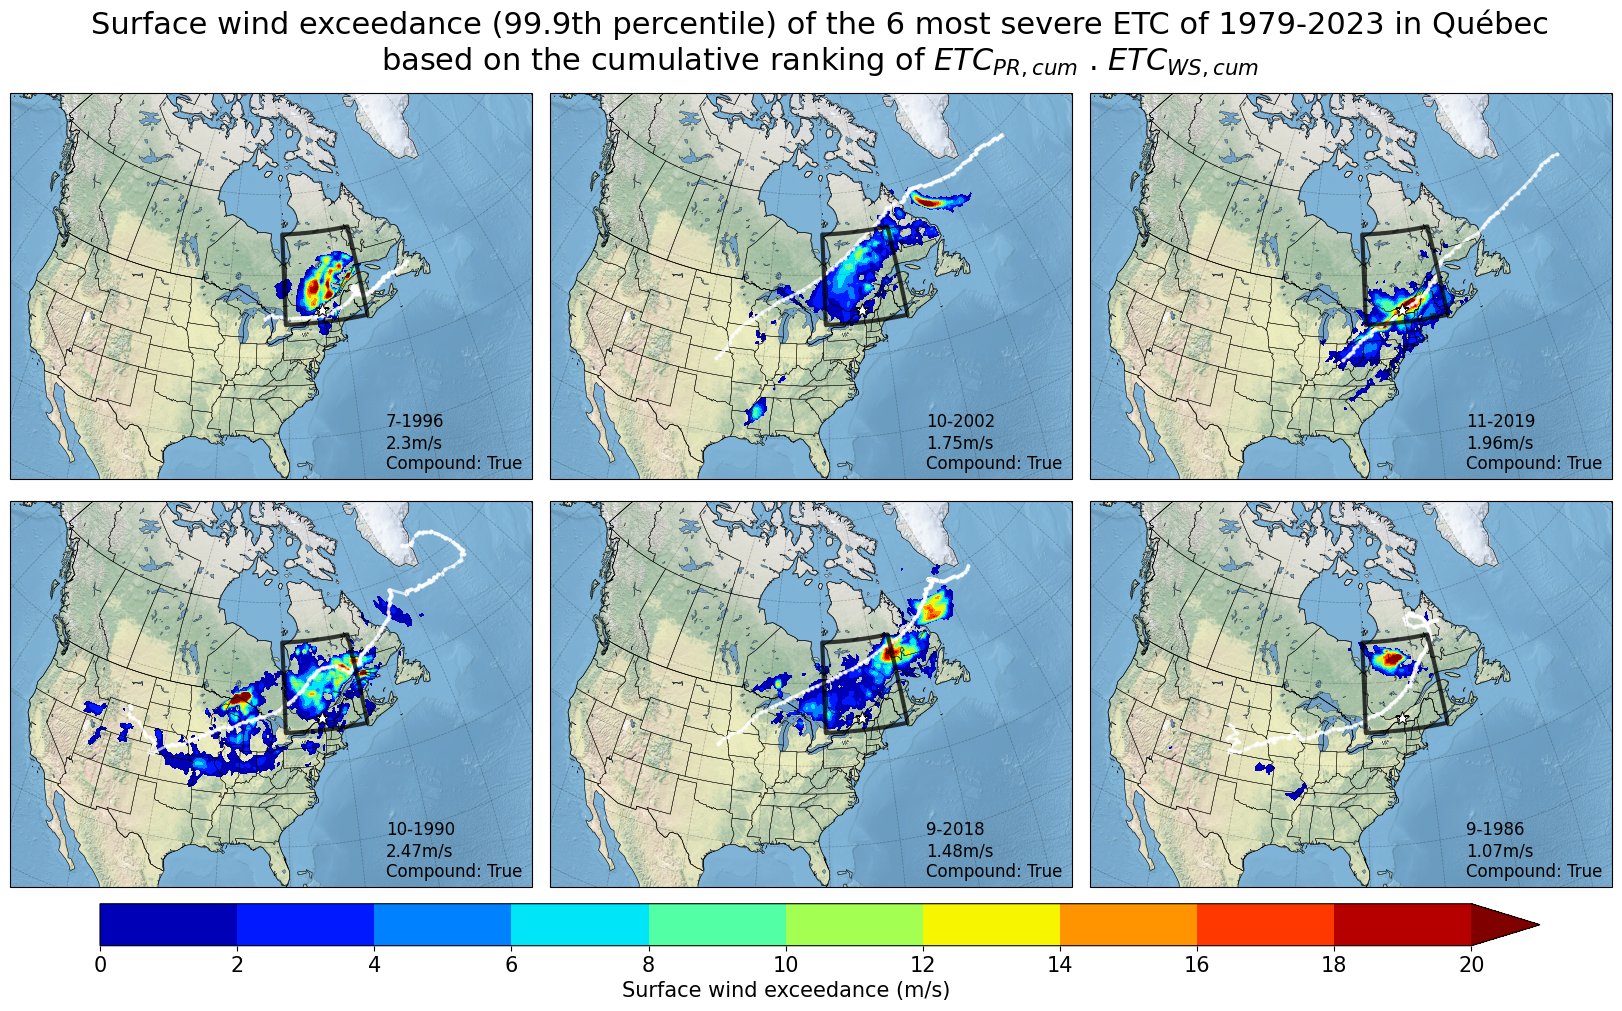

In [23]:
#Wind ranking cum
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 12))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, ax in tqdm(enumerate(axes)):    
    
    max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_rank[i])
    
    month_years = max_EETC['date'].dt.to_period('M').unique()
    ds = xr.open_zarr('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Wind_10m/Magnitude/era5_wind10_CORDEX_NA_1979-2023.zarr')
    ds = ds.sel(time=ds.time.dt.strftime('%Y-%m').isin(month_years.astype(str)))
    mask_diff_wind = ds - percentile_wind
    mask_diff_wind = mask_diff_wind.where(mask_diff_wind >= 0, np.nan)
    
    iEETC_list_wind = []
    for itrack, row in max_EETC.iterrows():        
        ilon, ilat, itime = row['lon'], row['lat'], row['date']

        mask_itime_wind = mask_diff_wind.sel(time=itime).where(mask_diff_wind.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).surf_wind
        
        iEETC_list_wind.append(mask_itime_wind.chunk({'longitude': -1, 'latitude': -1, 'quantile': -1}))

    iEETC_wind = xr.concat(iEETC_list_wind, dim='time') 
    iEETC_wind_exc = iEETC_wind.sum(dim=['time']) 

    ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

    mtl_lon, mtl_lat = -73.561668, 45.508888
    ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

    vmin = 0
    vmax = 20
    cmap = plt.get_cmap('jet')

    ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

    iEETC_wind_exc = iEETC_wind_exc.where(iEETC_wind_exc > 0, np.nan)

    sc = ax.contourf(iEETC_wind_exc['longitude'], iEETC_wind_exc['latitude'],
                     iEETC_wind_exc.sel(quantile=0.999), levels=np.linspace(vmin, vmax, int((vmax-vmin)/2)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
    ax.contour(
        Mask_NNA['longitude'],
        Mask_NNA['latitude'],
        Mask_NNA,
        levels=[0.99],
        linewidths=3,
        colors='black',
        alpha=0.75,
        transform=ccrs.PlateCarree(),
    )
    
    ax.text(0.72, 0.17,
        f"{EETC_cum_rank_min_pressure_dates[i].month}-{EETC_cum_rank_min_pressure_dates[i].year}\n"
        f"{np.round(EETC_dict[sorted_EETC_cum_rank[i]]['cum_wind'].sel(quantile=0.999).values.item(), 2)}m/s\n"
        f"Compound: {EETC_dict[sorted_EETC_cum_rank[i]]['compound_8hrs']['99.9']}",
        transform=ax.transAxes, fontsize=12, verticalalignment='top')
        
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 2))
cbar.set_label('Surface wind exceedance (m/s)', fontsize=15)
cbar.ax.tick_params(labelsize=15)

fig.suptitle(
    'Surface wind exceedance (99.9th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
    'based on the cumulative ranking of $\overline{{ETC}_{PR}}$ . $\overline{{ETC}_{WS}}$', 
    fontsize=22, y=0.93
)

6it [09:22, 93.72s/it] 


Text(0.5, 0.93, 'Precipitation exceedance (99.9th percentile) of the 6 most severe ETC of 1979-2023 in Québec\nbased on the cumulative ranking of $\\overline{{ETC}_{PR}}$ . $\\overline{{ETC}_{WS}}$')

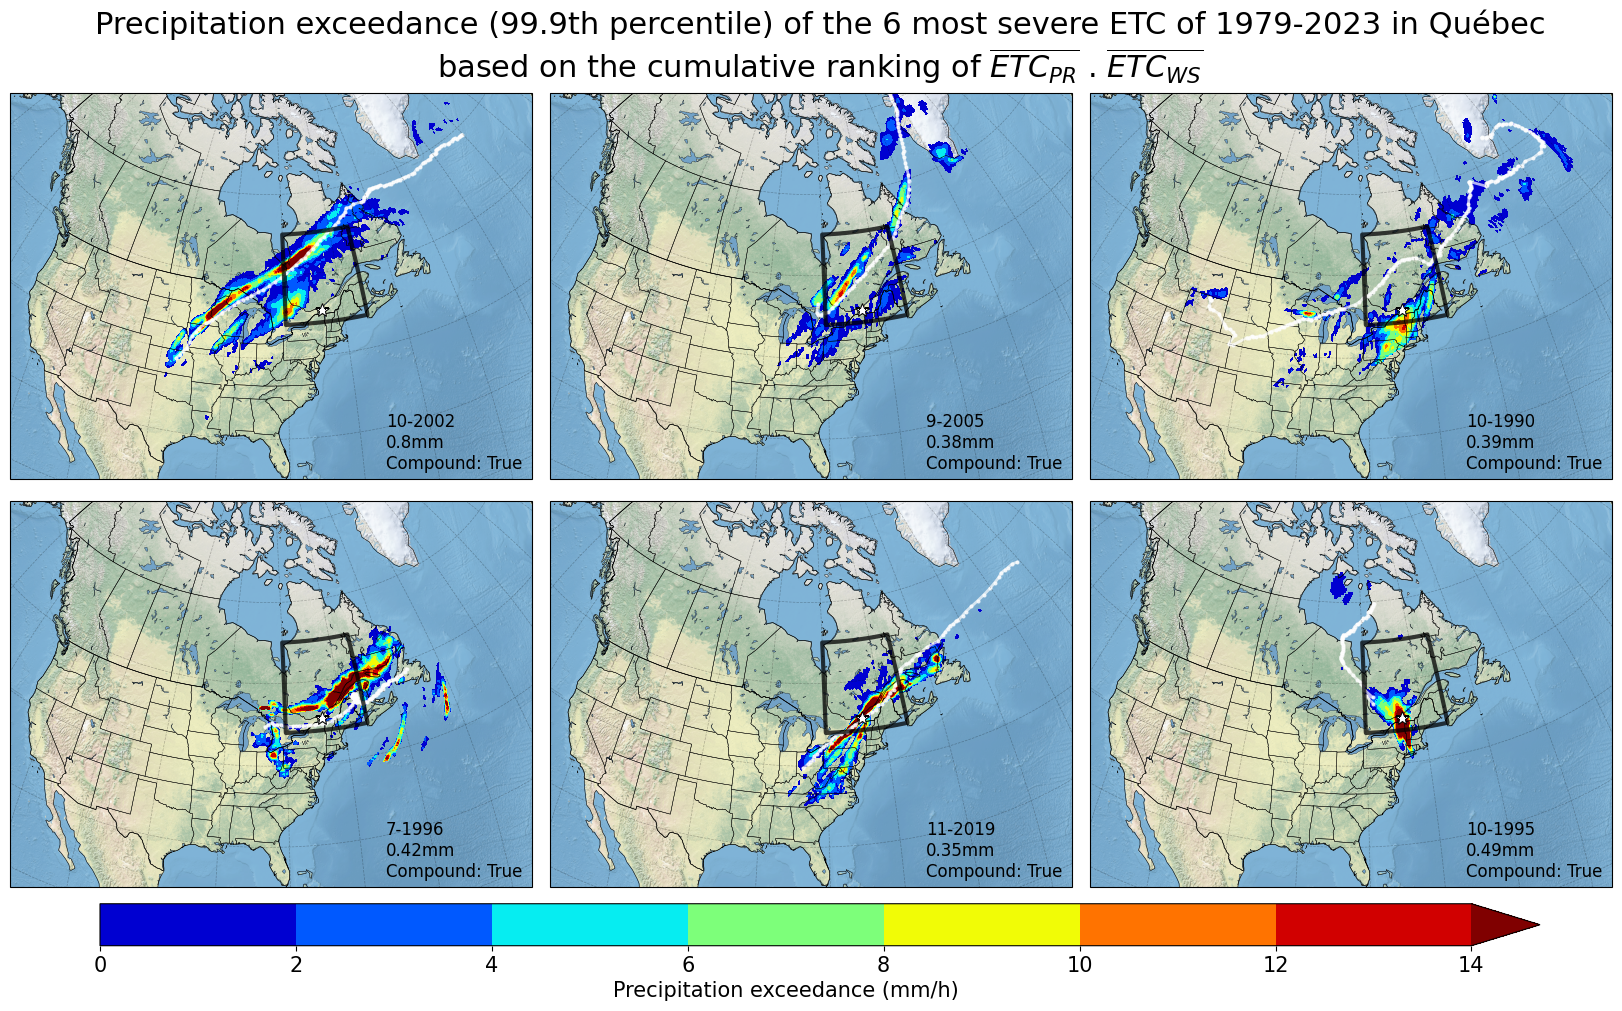

In [16]:
#Precip ranking cum
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 12))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, ax in tqdm(enumerate(axes)):    
    
    max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_avg_rank[i])
    
    month_years = max_EETC['date'].dt.to_period('M').unique()
    filenames = []
    for period in month_years:
        year = period.year
        month = period.month
        filenames.extend(braced_glob(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Precipitation/{year}/{month:02d}/era5_tp_ll_*_1h.nc4'))
    ds = xr.open_mfdataset(filenames)
    ds = ds.assign_coords({'longitude':(((ds['longitude'] + 180) % 360) - 180)})
    ds = ds.sortby(ds['longitude'])
    ds = ds.sel(longitude=slice(-171, -23), latitude=slice(76, 12))
    ds['tp'] = ds.tp * 1000.
    mask_diff_precip = ds - percentile_precip
    mask_diff_precip = mask_diff_precip.where(mask_diff_precip >= 0, np.nan)
    
    iEETC_list_precip = []
    for itrack, row in max_EETC.iterrows():        
        ilon, ilat, itime = row['lon'], row['lat'], row['date']

        mask_itime_precip = mask_diff_precip.sel(time=itime).where(mask_diff_precip.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).tp
        
        iEETC_list_precip.append(mask_itime_precip.chunk({'longitude': -1, 'latitude': -1, 'quantile': -1}))

    iEETC_precip = xr.concat(iEETC_list_precip, dim='time') 
    iEETC_precip_exc = iEETC_precip.sum(dim=['time']) 

    ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

    mtl_lon, mtl_lat = -73.561668, 45.508888
    ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

    vmin = 0
    vmax = 14
    cmap = plt.get_cmap('jet')

    ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

    iEETC_precip_exc = iEETC_precip_exc.where(iEETC_precip_exc > 0, np.nan)

    sc = ax.contourf(iEETC_precip_exc['longitude'], iEETC_precip_exc['latitude'],
                     iEETC_precip_exc.sel(quantile=0.999), levels=np.linspace(vmin, vmax, int((vmax-vmin)/2)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
    ax.contour(
        Mask_NNA['longitude'],
        Mask_NNA['latitude'],
        Mask_NNA,
        levels=[0.99],
        linewidths=3,
        colors='black',
        alpha=0.75,
        transform=ccrs.PlateCarree(),
    )
    
    ax.text(0.72, 0.17,
        f"{EETC_cum_avg_rank_min_pressure_dates[i].month}-{EETC_cum_avg_rank_min_pressure_dates[i].year}\n"
        f"{np.round(EETC_dict[sorted_EETC_cum_avg_rank[i]]['cum_avg_precip'].sel(quantile=0.999).values.item(), 2)}mm\n"
        f"Compound: {EETC_dict[sorted_EETC_cum_avg_rank[i]]['compound_8hrs']['99.9']}",
        transform=ax.transAxes, fontsize=12, verticalalignment='top')
        
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 2))
cbar.set_label('Precipitation exceedance (mm/h)', fontsize=15)
cbar.ax.tick_params(labelsize=15)

fig.suptitle(
    'Precipitation exceedance (99.9th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
    'based on the cumulative ranking of $\overline{{ETC}_{PR}}$ . $\overline{{ETC}_{WS}}$', 
    fontsize=22, y=0.93
)

6it [14:19, 143.21s/it]


Text(0.5, 0.93, 'Surface wind exceedance (99.9th percentile) of the 6 most severe ETC of 1979-2023 in Québec\nbased on the cumulative ranking of $\\overline{{ETC}_{PR}}$ . $\\overline{{ETC}_{WS}}$')

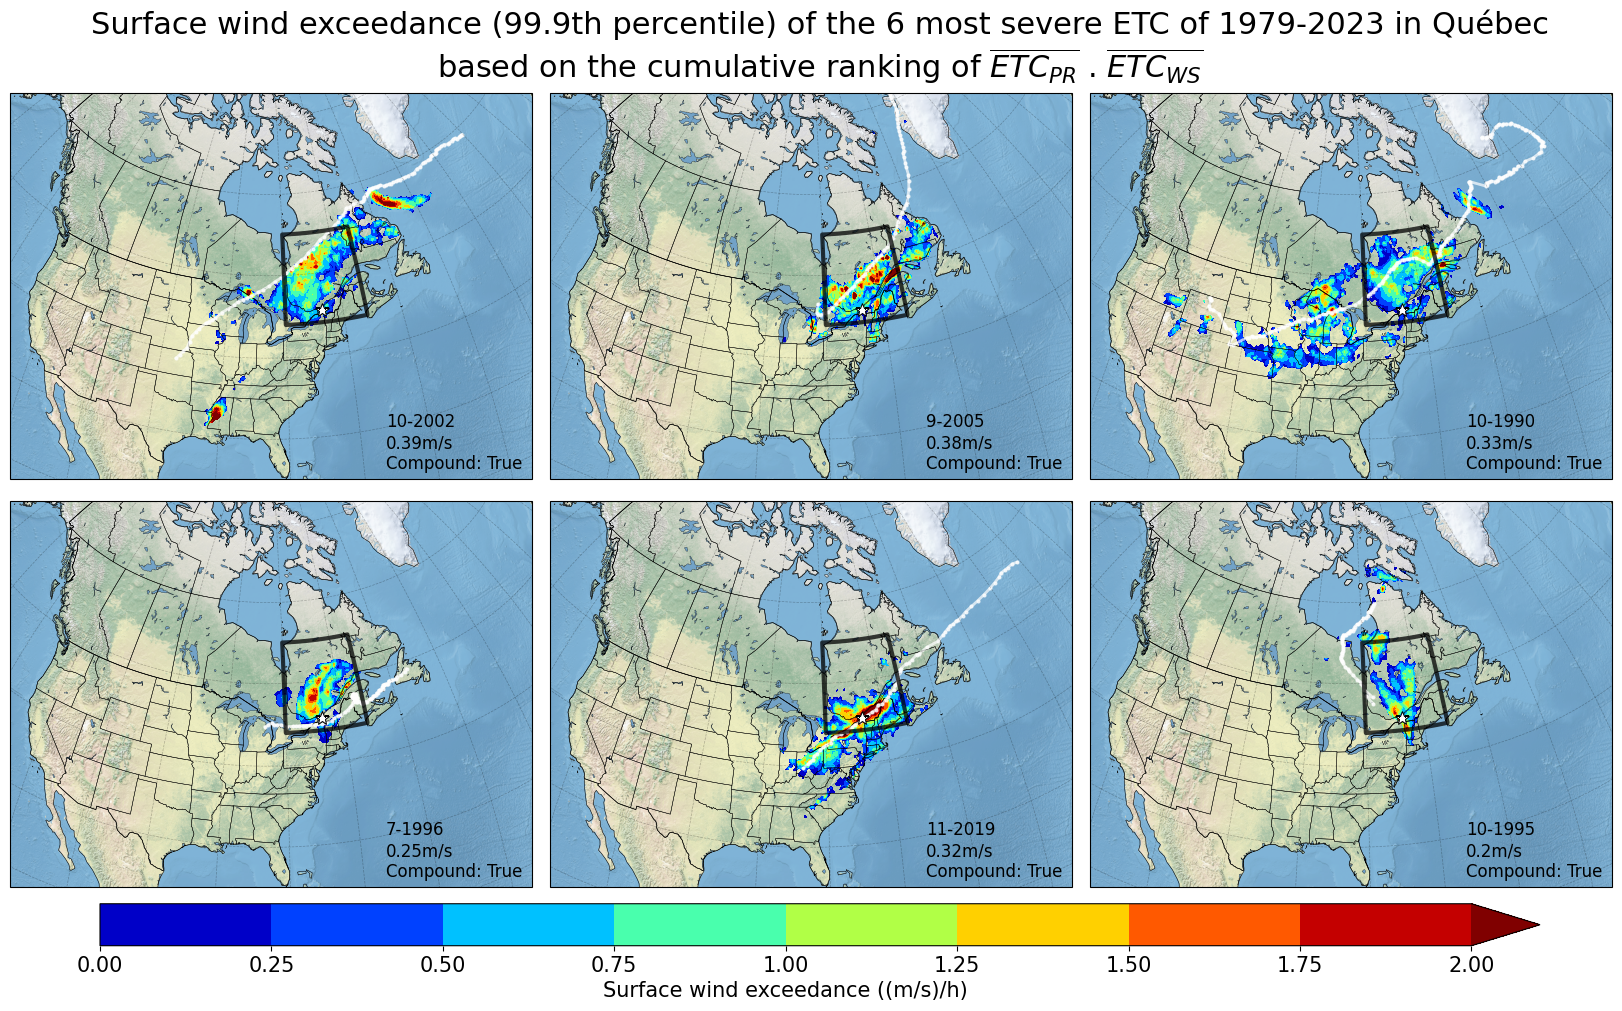

In [18]:
#Wind ranking cum_avg
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 12))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, ax in tqdm(enumerate(axes)):    
    
    max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_avg_rank[i])
    
    month_years = max_EETC['date'].dt.to_period('M').unique()
    ds = xr.open_zarr('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Wind_10m/Magnitude/era5_wind10_CORDEX_NA_1979-2023.zarr')
    ds = ds.sel(time=ds.time.dt.strftime('%Y-%m').isin(month_years.astype(str)))
    mask_diff_wind = ds - percentile_wind
    mask_diff_wind = mask_diff_wind.where(mask_diff_wind >= 0, np.nan)
    
    iEETC_list_wind = []
    for itrack, row in max_EETC.iterrows():        
        ilon, ilat, itime = row['lon'], row['lat'], row['date']

        mask_itime_wind = mask_diff_wind.sel(time=itime).where(mask_diff_wind.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).surf_wind
        
        iEETC_list_wind.append(mask_itime_wind.chunk({'longitude': -1, 'latitude': -1, 'quantile': -1}))

    iEETC_wind = xr.concat(iEETC_list_wind, dim='time') 
    iEETC_wind_exc = iEETC_wind.sum(dim=['time'])
    iEETC_wind_dur = iEETC_wind.where(iEETC_wind > 0).count(dim='time')    
    iEETC_wind_avexc = iEETC_wind_exc / iEETC_wind_dur.where(iEETC_wind_dur != 0)

    ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

    mtl_lon, mtl_lat = -73.561668, 45.508888
    ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

    vmin = 0
    vmax = 2
    cmap = plt.get_cmap('jet')

    ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

    iEETC_wind_avexc = iEETC_wind_avexc.where(iEETC_wind_avexc > 0, np.nan)

    sc = ax.contourf(iEETC_wind_avexc['longitude'], iEETC_wind_avexc['latitude'],
                     iEETC_wind_avexc.sel(quantile=0.999), levels=np.linspace(vmin, vmax, int((vmax-vmin)*4)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
    ax.contour(
        Mask_NNA['longitude'],
        Mask_NNA['latitude'],
        Mask_NNA,
        levels=[0.99],
        linewidths=3,
        colors='black',
        alpha=0.75,
        transform=ccrs.PlateCarree(),
    )
    
    ax.text(0.72, 0.17,
        f"{EETC_cum_avg_rank_min_pressure_dates[i].month}-{EETC_cum_avg_rank_min_pressure_dates[i].year}\n"
        f"{np.round(EETC_dict[sorted_EETC_cum_avg_rank[i]]['cum_avg_wind'].sel(quantile=0.999).values.item(), 2)}m/s\n"
        f"Compound: {EETC_dict[sorted_EETC_cum_avg_rank[i]]['compound_8hrs']['99.9']}",
        transform=ax.transAxes, fontsize=12, verticalalignment='top')
        
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02)
cbar.set_label('Surface wind exceedance ((m/s)/h)', fontsize=15)
cbar.ax.tick_params(labelsize=15)

fig.suptitle(
    'Surface wind exceedance (99.9th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
    'based on the cumulative ranking of $\overline{{ETC}_{PR}}$ . $\overline{{ETC}_{WS}}$', 
    fontsize=22, y=0.93
)

In [ ]:
# #Precip product cum
# plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
# fig = plt.figure(figsize=(18, 12))
# axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

# for i, ax in tqdm(enumerate(axes)):    
    
#     max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_wind_precip_product[i])
    
#     month_years = max_EETC['date'].dt.to_period('M').unique()
#     filenames = []
#     for period in month_years:
#         year = period.year
#         month = period.month
#         filenames.extend(braced_glob(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Precipitation/{year}/{month:02d}/era5_tp_ll_*_1h.nc4'))
#     ds = xr.open_mfdataset(filenames)
#     ds = ds.assign_coords({'longitude':(((ds['longitude'] + 180) % 360) - 180)})
#     ds = ds.sortby(ds['longitude'])
#     ds = ds.sel(longitude=slice(-171, -23), latitude=slice(76, 12))
#     ds['tp'] = ds.tp * 1000.
#     mask_diff_precip = ds - percentile_precip
#     mask_diff_precip = mask_diff_precip.where(mask_diff_precip >= 0, np.nan)
    
#     iEETC_list_precip = []
#     for itrack, row in max_EETC.iterrows():        
#         ilon, ilat, itime = row['lon'], row['lat'], row['date']

#         mask_itime_precip = mask_diff_precip.sel(time=itime).where(mask_diff_precip.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).tp
        
#         iEETC_list_precip.append(mask_itime_precip)

#     iEETC_precip = xr.concat(iEETC_list_precip, dim='time') 
#     iEETC_precip_exc = iEETC_precip.sum(dim=['time']) 

#     ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

#     borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
#     states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
#     lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
#     img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
#     ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
#     ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
#     ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
#     ax.coastlines(resolution='10m', linewidth=0.4, color='black')
#     ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
#     ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

#     mtl_lon, mtl_lat = -73.561668, 45.508888
#     ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

#     vmin = 0
#     vmax = 50
#     cmap = plt.get_cmap('jet')

#     ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

#     iEETC_precip_exc = iEETC_precip_exc.where(iEETC_precip_exc > 0, np.nan)

#     sc = ax.contourf(iEETC_precip_exc['longitude'], iEETC_precip_exc['latitude'],
#                      iEETC_precip_exc.sel(quantile=0.99), levels=np.linspace(vmin, vmax, int((vmax-vmin)/5)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
#     ax.contour(
#         Mask_NNA['longitude'],
#         Mask_NNA['latitude'],
#         Mask_NNA,
#         levels=[0.99],
#         linewidths=3,
#         colors='black',
#         alpha=0.75,
#         transform=ccrs.PlateCarree(),
#     )
    
#     ax.text(0.72, 0.17,
#         f"{EETC_cum_wind_precip_product_min_pressure_dates[i].month}-{EETC_cum_wind_precip_product_min_pressure_dates[i].year}\n"
#         f"{np.round(EETC_dict[sorted_EETC_cum_wind_precip_product[i]]['cum_precip'].sel(quantile=0.99).values.item(), 2)}mm\n"
#         f"Compound: {EETC_dict[sorted_EETC_cum_wind_precip_product[i]]['compound_8hrs']['99']}",
#         transform=ax.transAxes, fontsize=12, verticalalignment='top')
        
# cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
# cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 10))
# cbar.set_label('Precipitation exceedance (mm)', fontsize=15)
# cbar.ax.tick_params(labelsize=15)

# fig.suptitle(
#     'Precipitation exceedance (99th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
#     'based on the product $ETC_{PR, cum}$ . $ETC_{WS, cum}$', 
#     fontsize=22, y=0.93
# )

In [ ]:
# #Wind product cum
# plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
# fig = plt.figure(figsize=(18, 12))
# axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

# for i, ax in tqdm(enumerate(axes)):    
    
#     max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_wind_precip_product[i])
    
#     month_years = max_EETC['date'].dt.to_period('M').unique()
#     ds = xr.open_zarr('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Wind_10m/Magnitude/era5_wind10_CORDEX_NA_1979-2023.zarr')
#     ds = ds.sel(time=ds.time.dt.strftime('%Y-%m').isin(month_years.astype(str)))
#     mask_diff_wind = ds - percentile_wind
#     mask_diff_wind = mask_diff_wind.where(mask_diff_wind >= 0, np.nan)
    
#     iEETC_list_wind = []
#     for itrack, row in max_EETC.iterrows():        
#         ilon, ilat, itime = row['lon'], row['lat'], row['date']

#         mask_itime_wind = mask_diff_wind.sel(time=itime).where(mask_diff_wind.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).surf_wind
        
#         iEETC_list_wind.append(mask_itime_wind)

#     iEETC_wind = xr.concat(iEETC_list_wind, dim='time') 
#     iEETC_wind_exc = iEETC_wind.sum(dim=['time']) 

#     ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

#     borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
#     states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
#     lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
#     img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
#     ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
#     ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
#     ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
#     ax.coastlines(resolution='10m', linewidth=0.4, color='black')
#     ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
#     ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

#     mtl_lon, mtl_lat = -73.561668, 45.508888
#     ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

#     vmin = 0
#     vmax = 150
#     cmap = plt.get_cmap('jet')

#     ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

#     iEETC_wind_exc = iEETC_wind_exc.where(iEETC_wind_exc > 0, np.nan)

#     sc = ax.contourf(iEETC_wind_exc['longitude'], iEETC_wind_exc['latitude'],
#                      iEETC_wind_exc.sel(quantile=0.99), levels=np.linspace(vmin, vmax, int((vmax-vmin)/10)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
#     ax.contour(
#         Mask_NNA['longitude'],
#         Mask_NNA['latitude'],
#         Mask_NNA,
#         levels=[0.99],
#         linewidths=3,
#         colors='black',
#         alpha=0.75,
#         transform=ccrs.PlateCarree(),
#     )
        
#     ax.text(0.72, 0.17,
#         f"{EETC_cum_wind_precip_product_min_pressure_dates[i].month}-{EETC_cum_wind_precip_product_min_pressure_dates[i].year}\n"
#         f"{np.round(EETC_dict[sorted_EETC_cum_wind_precip_product[i]]['cum_wind'].sel(quantile=0.99).values.item(), 2)}m/s\n"
#         f"Compound: {EETC_dict[sorted_EETC_cum_wind_precip_product[i]]['compound_8hrs']['99']}",
#         transform=ax.transAxes, fontsize=12, verticalalignment='top')
        
# cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
# cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 10))
# cbar.set_label('Surface wind exceedance (m/s)', fontsize=15)
# cbar.ax.tick_params(labelsize=15)

# fig.suptitle(
#     'Surface wind exceedance (99th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
#     'based on the product $ETC_{PR, cum}$ . $ETC_{WS, cum}$', 
#     fontsize=22, y=0.93
# )

In [ ]:
# #Precip product cum_avg
# plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
# fig = plt.figure(figsize=(18, 12))
# axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

# for i, ax in tqdm(enumerate(axes)):    
    
#     max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_avg_wind_precip_product[i])
    
#     month_years = max_EETC['date'].dt.to_period('M').unique()
#     filenames = []
#     for period in month_years:
#         year = period.year
#         month = period.month
#         filenames.extend(braced_glob(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Precipitation/{year}/{month:02d}/era5_tp_ll_*_1h.nc4'))
#     ds = xr.open_mfdataset(filenames)
#     ds = ds.assign_coords({'longitude':(((ds['longitude'] + 180) % 360) - 180)})
#     ds = ds.sortby(ds['longitude'])
#     ds = ds.sel(longitude=slice(-171, -23), latitude=slice(76, 12))
#     ds['tp'] = ds.tp * 1000.
#     mask_diff_precip = ds - percentile_precip
#     mask_diff_precip = mask_diff_precip.where(mask_diff_precip >= 0, np.nan)
    
#     iEETC_list_precip = []
#     for itrack, row in max_EETC.iterrows():        
#         ilon, ilat, itime = row['lon'], row['lat'], row['date']

#         mask_itime_precip = mask_diff_precip.sel(time=itime).where(mask_diff_precip.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).tp
        
#         iEETC_list_precip.append(mask_itime_precip)

#     iEETC_precip = xr.concat(iEETC_list_precip, dim='time') 
#     iEETC_precip_exc = iEETC_precip.sum(dim=['time'])
#     iEETC_precip_dur = iEETC_precip.where(iEETC_precip > 0).count(dim='time')
#     iEETC_precip_avexc = iEETC_precip_exc / iEETC_precip_dur.where(iEETC_precip_dur != 0)
        
#     ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

#     borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
#     states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
#     lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
#     img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
#     ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
#     ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
#     ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
#     ax.coastlines(resolution='10m', linewidth=0.4, color='black')
#     ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
#     ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

#     mtl_lon, mtl_lat = -73.561668, 45.508888
#     ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

#     vmin = 0
#     vmax = 5
#     cmap = plt.get_cmap('jet')

#     ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

#     iEETC_precip_avexc = iEETC_precip_avexc.where(iEETC_precip_avexc > 0, np.nan)

#     sc = ax.contourf(iEETC_precip_avexc['longitude'], iEETC_precip_avexc['latitude'],
#                      iEETC_precip_avexc.sel(quantile=0.99), levels=np.linspace(vmin, vmax, int((vmax-vmin)*2)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
#     ax.contour(
#         Mask_NNA['longitude'],
#         Mask_NNA['latitude'],
#         Mask_NNA,
#         levels=[0.99],
#         linewidths=3,
#         colors='black',
#         alpha=0.75,
#         transform=ccrs.PlateCarree(),
#     )
    
#     ax.text(0.72, 0.17,
#         f"{EETC_cum_avg_wind_precip_product_min_pressure_dates[i].month}-{EETC_cum_avg_wind_precip_product_min_pressure_dates[i].year}\n"
#         f"{np.round(EETC_dict[sorted_EETC_cum_avg_wind_precip_product[i]]['cum_avg_precip'].sel(quantile=0.99).values.item(), 2)}mm/h\n"
#         f"Compound: {EETC_dict[sorted_EETC_cum_avg_wind_precip_product[i]]['compound_8hrs']['99']}",
#         transform=ax.transAxes, fontsize=12, verticalalignment='top')

# cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
# cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 1))
# cbar.set_label('Average precipitation exceedance (mm/h)', fontsize=15)
# cbar.ax.tick_params(labelsize=15)

# fig.suptitle(
#     'Average precipitation exceedance (99th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
#     'based on the product $\overline{{ETC}_{PR}}$ . $\overline{{ETC}_{WS}}$', 
#     fontsize=22, y=0.93
# )

In [ ]:
# #Wind product cum_avg
# plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
# fig = plt.figure(figsize=(18, 12))
# axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

# for i, ax in tqdm(enumerate(axes)):    
    
#     max_EETC = df.groupby('storm').get_group(sorted_EETC_cum_avg_wind_precip_product[i])
    
#     month_years = max_EETC['date'].dt.to_period('M').unique()
#     ds = xr.open_zarr('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Wind_10m/Magnitude/era5_wind10_CORDEX_NA_1979-2023.zarr')
#     ds = ds.sel(time=ds.time.dt.strftime('%Y-%m').isin(month_years.astype(str)))
#     mask_diff_wind = ds - percentile_wind
#     mask_diff_wind = mask_diff_wind.where(mask_diff_wind >= 0, np.nan)
    
#     iEETC_list_wind = []
#     for itrack, row in max_EETC.iterrows():        
#         ilon, ilat, itime = row['lon'], row['lat'], row['date']

#         mask_itime_wind = mask_diff_wind.sel(time=itime).where(mask_diff_wind.sel(time=itime).map(lambda x: haversine(ilon, ilat, x.longitude, x.latitude) <= 1000), drop=True).surf_wind
        
#         iEETC_list_wind.append(mask_itime_wind)

#     iEETC_wind = xr.concat(iEETC_list_wind, dim='time') 
#     iEETC_wind_exc = iEETC_wind.sum(dim=['time']) 
#     iEETC_wind_dur = iEETC_wind.where(iEETC_wind > 0).count(dim='time')    
#     iEETC_wind_avexc = iEETC_wind_exc / iEETC_wind_dur.where(iEETC_wind_dur != 0)
    
#     ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

#     borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
#     states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
#     lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
#     img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
#     ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
#     ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
#     ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
#     ax.coastlines(resolution='10m', linewidth=0.4, color='black')
#     ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
#     ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

#     mtl_lon, mtl_lat = -73.561668, 45.508888
#     ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

#     vmin = 0
#     vmax = 5
#     cmap = plt.get_cmap('jet')

#     ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='white', alpha=0.7, marker='o', markersize=2)

#     iEETC_wind_avexc = iEETC_wind_avexc.where(iEETC_wind_avexc > 0, np.nan)

#     sc = ax.contourf(iEETC_wind_avexc['longitude'], iEETC_wind_avexc['latitude'],
#                      iEETC_wind_avexc.sel(quantile=0.99), levels=np.linspace(vmin, vmax, int((vmax-vmin)*2)+1), extend='max', cmap=cmap, transform=ccrs.PlateCarree())
    
#     ax.contour(
#         Mask_NNA['longitude'],
#         Mask_NNA['latitude'],
#         Mask_NNA,
#         levels=[0.99],
#         linewidths=3,
#         colors='black',
#         alpha=0.75,
#         transform=ccrs.PlateCarree(),
#     )
    
#     ax.text(0.72, 0.17,
#         f"{EETC_cum_avg_wind_precip_product_min_pressure_dates[i].month}-{EETC_cum_avg_wind_precip_product_min_pressure_dates[i].year}\n"
#         f"{np.round(EETC_dict[sorted_EETC_cum_avg_wind_precip_product[i]]['cum_avg_wind'].sel(quantile=0.99).values.item(), 2)}m/s\n"
#         f"Compound: {EETC_dict[sorted_EETC_cum_avg_wind_precip_product[i]]['compound_8hrs']['99']}",
#         transform=ax.transAxes, fontsize=12, verticalalignment='top')
        
# cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]    
# cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 1))
# cbar.set_label('Average surface wind exceedance (m/s)', fontsize=15)
# cbar.ax.tick_params(labelsize=15)

# fig.suptitle(
#     'Average surface wind exceedance (99th percentile) of the 6 most severe ETC of 1979-2023 in Québec\n'
#     'based on the product $\overline{{ETC}_{PR}}$ . $\overline{{ETC}_{WS}}$', 
#     fontsize=22, y=0.93
# )

## Cellule de test pour le tracé des cartes

6it [00:00, 17.25it/s]


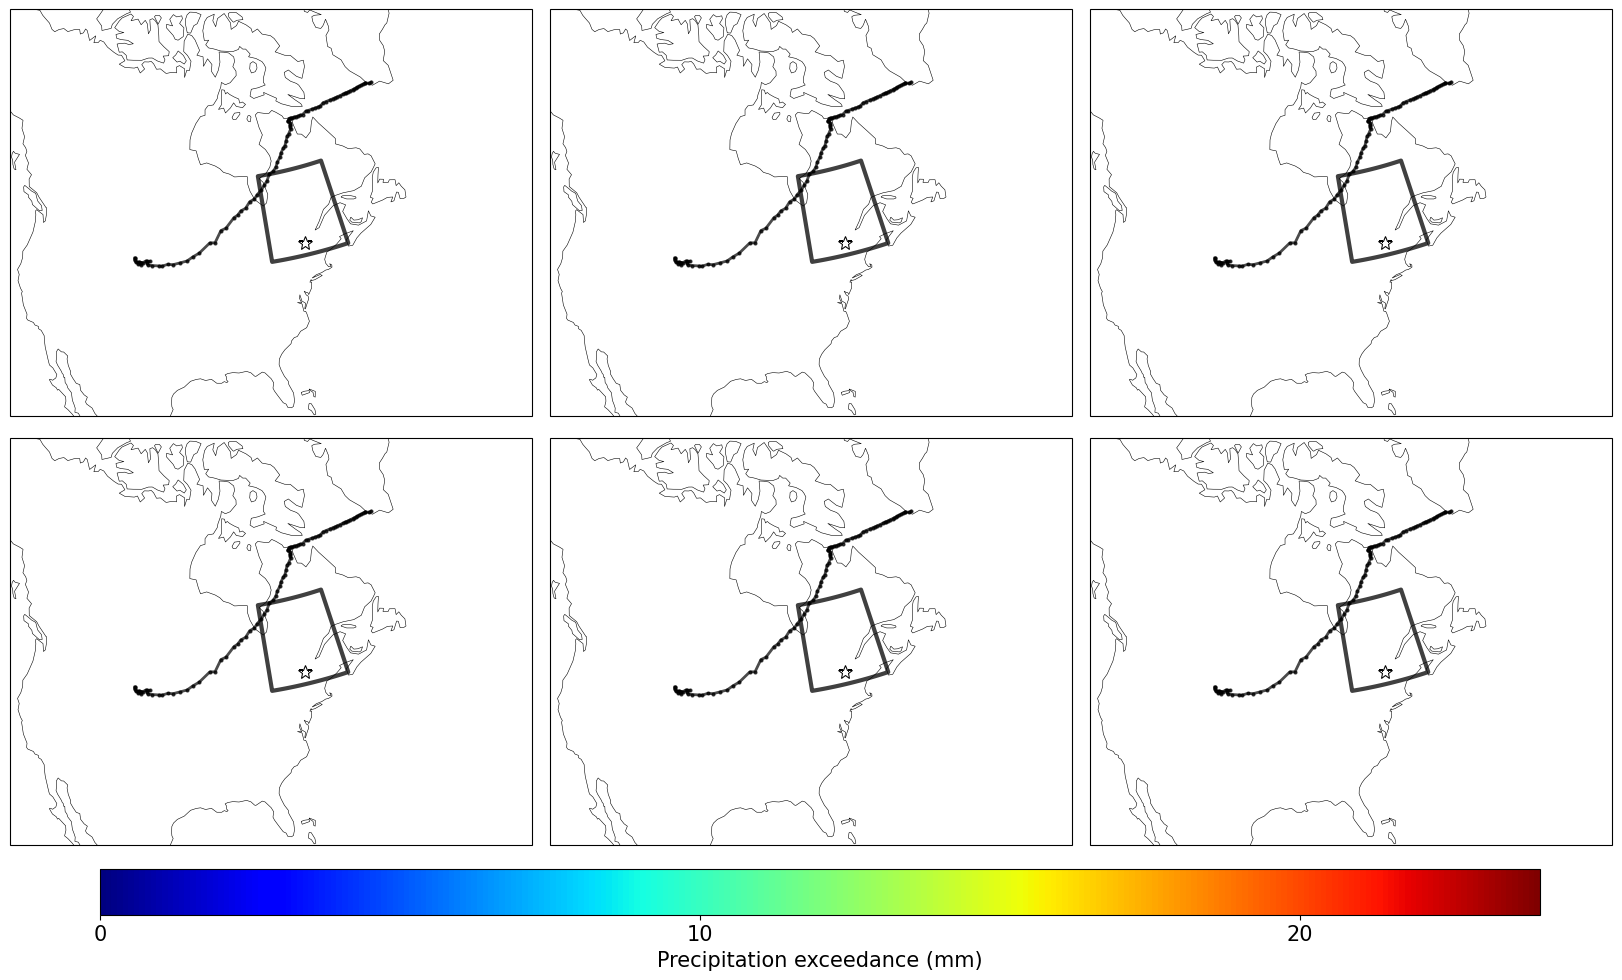

In [13]:
#For test purposes

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 13))
positions = [
    [0.05, 0.44, 0.29, 0.50],  # Rangée du haut, Colonne 1
    [0.35, 0.44, 0.29, 0.50],  # Rangée du haut, Colonne 2
    [0.65, 0.44, 0.29, 0.50],  # Rangée du haut, Colonne 3
    [0.05, 0.11, 0.29, 0.50],  # Rangée du bas, Colonne 1
    [0.35, 0.11, 0.29, 0.50],  # Rangée du bas, Colonne 2
    [0.65, 0.11, 0.29, 0.50],  # Rangée du bas, Colonne 3
]

axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, ax in tqdm(enumerate(axes)):

    ax.set_extent([-120, -45, 70, 25], crs=ccrs.PlateCarree())

    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    mtl_lon, mtl_lat = -73.561668, 45.508888
    ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=0.75, markeredgecolor='black', 
            zorder=3, transform=ccrs.PlateCarree())

    ax.plot(max_EETC['lon'], max_EETC['lat'], transform=ccrs.PlateCarree(), lw=2, c='black', alpha=0.7, marker='o', markersize=2)

    ax.contour(
        Mask_NNA['longitude'],
        Mask_NNA['latitude'],
        Mask_NNA,
        levels=[0.99],
        linewidths=3,
        colors='black',
        alpha=0.75,
        transform=ccrs.PlateCarree(),
    )

    # ax.text(0.72, 0.17,
    #     f"{EETC_cum_wind_precip_product_min_pressure_dates[i].month}-{EETC_cum_wind_precip_product_min_pressure_dates[i].year}\n"
    #     f"{np.round(EETC_dict[sorted_EETC_cum_wind_precip_product[i]]['cum_wind'].sel(quantile=0.99).values.item(), 2)}mm\n"
    #     f"Compound: {EETC_dict[sorted_EETC_cum_wind_precip_product[i]]['compound_8hrs']['99']}",
    #     transform=ax.transAxes, fontsize=12, verticalalignment='top')

cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, ticks=range(vmin, vmax+1, 10))
cbar.set_label('Precipitation exceedance (mm)', fontsize=15)
cbar.ax.tick_params(labelsize=15)

# fig.suptitle(
#     'Precipitation exceedance vs 99th percentile of the 6 most severe ETC of 1979-2023 in Québec\n'
#     'based on the product $ETC_{precip, cum}$ . $ETC_{wind, cum}$', 
#     fontsize=22, y=0.93  # Remonte le titre si besoin
# )